In [1]:
# !pip3 install fairlearn

In [2]:
# Notebook based on https://fairlearn.org/v0.13/quickstart.html

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fairlearn.datasets import fetch_diabetes_hospital
data = fetch_diabetes_hospital(as_frame=True)
X = data.data.copy()
X.drop(columns=["readmitted", "readmit_binary"], inplace=True)
y = data.target
X_ohe = pd.get_dummies(X)
sensitiv = X['gender']


In [4]:
X.columns
# race.value_counts()

Index(['race', 'gender', 'age', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'primary_diagnosis', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid',
       'had_emergency', 'had_inpatient_days', 'had_outpatient_days'],
      dtype='str')

## Basic stats about predictions

In [5]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
np.random.seed(42)  # set seed for consistent results
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X_ohe, y, sensitiv, random_state=123)
classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)
classifier.fit(X_train, y_train)

# threshold since we get probabilities predicted
y_pred = (classifier.predict_proba(X_test)[:,1] >= 0.1)

In [6]:
# accuracy per group
mf_acc = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("overall accuracy = ",mf_acc.overall.item())
print("by group: ")
print(mf_acc.by_group)

overall accuracy =  0.5148573225375364
by group: 
gender
Female             0.499237
Male               0.533231
Unknown/Invalid    1.000000
Name: accuracy_score, dtype: float64


In [7]:
# selection rate (percentage predicted in the positive class)
mf = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("overall selection rate = ",mf.overall.item())
print("by group: ")
print(mf.by_group)

overall selection rate =  0.5275528653407751
by group: 
gender
Female             0.546531
Male               0.505224
Unknown/Invalid    0.000000
Name: selection_rate, dtype: float64


In [8]:
# FPR (false positive rate)
from fairlearn.metrics import false_positive_rate
mf_fpr = MetricFrame(metrics=false_positive_rate, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("overall FPR = ",mf_fpr.overall.item())
print("by group: ")
print(mf_fpr.by_group)

overall FPR =  0.5071425412409889
by group: 
gender
Female             0.526674
Male               0.484289
Unknown/Invalid    0.000000
Name: false_positive_rate, dtype: float64


In [9]:
# TPR (true positive rate)
from fairlearn.metrics import true_positive_rate
mf_tpr = MetricFrame(metrics=true_positive_rate, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
print("overall TPR = ",mf_tpr.overall.item())
print("by group: ")
print(mf_tpr.by_group)

overall TPR =  0.6905687036382904
by group: 
gender
Female             0.701665
Male               0.676911
Unknown/Invalid    0.000000
Name: true_positive_rate, dtype: float64


## Evaluating fairness

In [10]:
# Demographic parity = all groups should predict the positive class equally (i.e. equal selection rate))
from fairlearn.metrics import demographic_parity_difference
from fairlearn.metrics import demographic_parity_ratio

demog_parity_diff = demographic_parity_difference(y_test,
                                    y_pred,
                                    sensitive_features=A_test)
demog_parity_ratio = demographic_parity_ratio(y_test,
                               y_pred,
                               sensitive_features=A_test)

print("Demographic parity difference = ",demog_parity_diff)
print("Demographic parity ratio = ",demog_parity_ratio)


Demographic parity difference =  0.546531057028696
Demographic parity ratio =  0.0


## Mitigations (in-processing)

In [11]:
from fairlearn.reductions import ErrorRate, EqualizedOdds, ExponentiatedGradient
objective = ErrorRate(costs={'fp': 0.1, 'fn': 0.9})
constraint = EqualizedOdds(difference_bound=0.01)

classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)

mitigator = ExponentiatedGradient(classifier, constraint, objective=objective)
mitigator.fit(X_train, y_train, sensitive_features=A_train)

y_pred_mitigated = mitigator.predict(X_test)

In [12]:
# accuracy per group
mf_acc = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=A_test)
print("overall accuracy = ",mf_acc.overall.item())
print("by group: ")
print(mf_acc.by_group)

overall accuracy =  0.5188664413175065
by group: 
gender
Female             0.508827
Male               0.530661
Unknown/Invalid    1.000000
Name: accuracy_score, dtype: float64


In [13]:
# selection rate (percentage predicted in the positive class)
mf = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=A_test)
print("overall selection rate = ",mf.overall.item())
print("by group: ")
print(mf.by_group)

overall selection rate =  0.5230720855278673
by group: 
gender
Female             0.534762
Male               0.509335
Unknown/Invalid    0.000000
Name: selection_rate, dtype: float64


In [14]:
# FPR (false positive rate)
from fairlearn.metrics import false_positive_rate
mf_fpr = MetricFrame(metrics=false_positive_rate, y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=A_test)
print("overall FPR = ",mf_fpr.overall.item())
print("by group: ")
print(mf_fpr.by_group)

overall FPR =  0.5023661049931449
by group: 
gender
Female             0.514628
Male               0.488037
Unknown/Invalid    0.000000
Name: false_positive_rate, dtype: float64


In [15]:
# TPR (true positive rate)
from fairlearn.metrics import true_positive_rate
mf_tpr = MetricFrame(metrics=true_positive_rate, y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=A_test)
print("overall TPR = ",mf_tpr.overall.item())
print("by group: ")
print(mf_tpr.by_group)

overall TPR =  0.6884493111974568
by group: 
gender
Female             0.692061
Male               0.684003
Unknown/Invalid    0.000000
Name: true_positive_rate, dtype: float64


In [16]:
# Demographic parity = all groups should predict the positive class equally (i.e. equal selection rate))
from fairlearn.metrics import demographic_parity_difference
from fairlearn.metrics import demographic_parity_ratio

demog_parity_diff = demographic_parity_difference(y_test,
                                    y_pred_mitigated,
                                    sensitive_features=A_test)
demog_parity_ratio = demographic_parity_ratio(y_test,
                               y_pred_mitigated,
                               sensitive_features=A_test)

print("Demographic parity difference = ",demog_parity_diff)
print("Demographic parity ratio = ",demog_parity_ratio)


Demographic parity difference =  0.5347620777333818
Demographic parity ratio =  0.0


In [17]:
# Demographic parity = all groups should predict the positive class equally (i.e. equal selection rate))
from fairlearn.metrics import equalized_odds_difference
from fairlearn.metrics import equalized_odds_ratio

equal_odds_diff = equalized_odds_difference(y_test,
                                    y_pred_mitigated,
                                    sensitive_features=A_test)
equal_odds_ratio = equalized_odds_ratio(y_test,
                               y_pred_mitigated,
                               sensitive_features=A_test)

print("Equalized odds difference = ",equal_odds_diff)
print("equalized odds ration ratio = ",equal_odds_ratio)


Equalized odds difference =  0.6920614596670934
equalized odds ration ratio =  0.0


# Equalized odds

The order is a bit weird because I already added this cell below the mitigation cells, oops.

In [18]:
# Demographic parity = all groups should predict the positive class equally (i.e. equal selection rate))
from fairlearn.metrics import equalized_odds_difference
from fairlearn.metrics import equalized_odds_ratio

equal_odds_diff = equalized_odds_difference(y_test,
                                    y_pred,
                                    sensitive_features=A_test)
equal_odds_ratio = equalized_odds_ratio(y_test,
                               y_pred,
                               sensitive_features=A_test)

print("Equalized odds difference = ",equal_odds_diff)
print("equalized odds ration ratio = ",equal_odds_ratio)


Equalized odds difference =  0.7016645326504481
equalized odds ration ratio =  0.0


In [19]:
print(X_test.keys())

Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_diagnoses', 'race_AfricanAmerican',
       'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other',
       'race_Unknown', 'gender_Female', 'gender_Male',
       'gender_Unknown/Invalid', 'age_'30 years or younger'',
       'age_'30-60 years'', 'age_'Over 60 years'',
       'discharge_disposition_id_'Discharged to Home'',
       'discharge_disposition_id_Other', 'admission_source_id_Emergency',
       'admission_source_id_Other', 'admission_source_id_Referral',
       'medical_specialty_Cardiology', 'medical_specialty_Emergency/Trauma',
       'medical_specialty_Family/GeneralPractice',
       'medical_specialty_InternalMedicine', 'medical_specialty_Missing',
       'medical_specialty_Other', 'primary_diagnosis_'Genitourinary Issues'',
       'primary_diagnosis_'Musculoskeletal Issues'',
       'primary_diagnosis_'Respiratory Issues'', 'primary_diagnosis_Diabetes',
       'primary

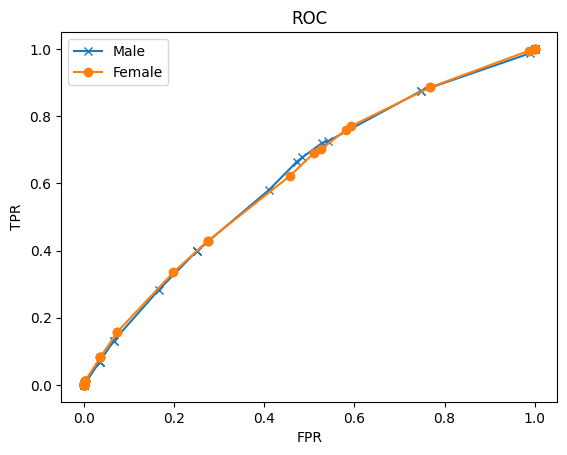

In [27]:
import numpy as np

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X_ohe, y, sensitiv, random_state=123)
classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)
classifier.fit(X_train, y_train)

X_test_male = X_test[X_test["gender_Male"]]
X_test_female = X_test[X_test["gender_Female"]]

y_test_male = y_test[X_test["gender_Male"]]
y_test_female = y_test[X_test["gender_Female"]]

tpr_male = []
tpr_female = []

fpr_male = []
fpr_female = []

for threshold in np.linspace(0, 1, 100):
    y_pred_male = (classifier.predict_proba(X_test_male)[:,1] >= threshold)
    y_pred_female = (classifier.predict_proba(X_test_female)[:,1] >= threshold)
    tpr_male.append(true_positive_rate(y_test_male, y_pred_male))
    tpr_female.append(true_positive_rate(y_test_female, y_pred_female))
    fpr_male.append(false_positive_rate(y_test_male, y_pred_male))
    fpr_female.append(false_positive_rate(y_test_female, y_pred_female))

plt.plot(fpr_male, tpr_male, "x-")
plt.plot(fpr_female, tpr_female, "o-")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC")

plt.legend(["Male", "Female"])

plt.savefig("ROC.pdf", format="pdf", bbox_inches="tight")

In [28]:
# Demographic parity = all groups should predict the positive class equally (i.e. equal selection rate))
from fairlearn.metrics import equalized_odds_difference
from fairlearn.metrics import equalized_odds_ratio

y_pred = (classifier.predict_proba(X_test)[:,1] >= 0.35)

equal_odds_diff = equalized_odds_difference(y_test,
                                    y_pred,
                                    sensitive_features=A_test)
equal_odds_ratio = equalized_odds_ratio(y_test,
                               y_pred,
                               sensitive_features=A_test)

print("Equalized odds difference = ",equal_odds_diff)
print("equalized odds ration ratio = ",equal_odds_ratio)


Equalized odds difference =  0.0019206145966709346
equalized odds ration ratio =  0.0
